# 06 · Evaluación — Importancia de variables (XGBoost tuneado)

¿Qué variables sostienen las predicciones del modelo? Cruzamos **dos lentes
complementarias**, porque ninguna es suficiente por sí sola:

## 1. Importancia nativa de XGBoost (basada en la estructura de los árboles)

XGBoost ofrece tres definiciones, calculadas sobre cómo se usaron las variables al
construir los árboles:

- **`gain`** (la de `feature_importances_`): mejora promedio en la función de
  pérdida que aporta cada *split* sobre esa variable. Es la más informativa de las
  tres — mide *cuánto ayuda a separar*.
- **`weight`** (frecuencia): cuántas veces se usó la variable para partir. Sesgada
  hacia variables continuas / de alta cardinalidad (ofrecen más puntos de corte).
- **`cover`**: nº promedio de observaciones afectadas por los splits de la variable.

**Limitación**: son importancias *del entrenamiento*, no de la generalización, y se
reparten de forma arbitraria entre variables correlacionadas (y aquí hay mucha
correlación entre las ventanas RFM u3/u6/u12).

## 2. Importancia por permutación (basada en el rendimiento fuera de muestra)

Se mide sobre el **test OOT**: se baraja aleatoriamente una variable y se observa
**cuánto cae el AUC**. Si romper la variable degrada el modelo, la variable
aportaba señal *que generaliza*. Es model-agnostic y honesta respecto a producción.

**Limitación**: ante dos variables muy correlacionadas, permutar una sola apenas
mueve el AUC (la otra la sustituye) → puede *subestimar* a ambas. Por eso la leemos
junto a la nativa, no en su lugar.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent

df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
X_test, y_test = X[test_mask], y[test_mask]

# --- cargar el modelo tuneado (o reconstruirlo desde los hiperparámetros) ---
model_path = base / "models" / "xgboost_tuned.joblib"
params_path = base / "05_modelling" / "xgboost_best_params.json"
if model_path.exists():
    model = joblib.load(model_path)
    print(f"modelo cargado: {model_path.relative_to(base)}")
else:
    if not params_path.exists():
        raise FileNotFoundError(
            "Falta el modelo. Corre primero 05_modelling/02_tuning_xgboost_optuna.ipynb "
            "(secciones 2 y 6) para generar models/xgboost_tuned.joblib.")
    best = json.load(open(params_path))["best_params"]
    spw = (y[train_mask] == 0).sum() / (y[train_mask] == 1).sum()
    model = XGBClassifier(**best, scale_pos_weight=spw, eval_metric="logloss",
                          tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X[train_mask], y[train_mask])
    print("modelo reconstruido desde hiperparámetros y entrenado en train OOT")

# El modelo está entrenado sobre el train OOT → lo explicamos/evaluamos sobre el
# test OOT (fuera de muestra). Para el modelo desplegado se reentrenaría con todo.
p_test = model.predict_proba(X_test)[:, 1]
print(f"test OOT: {test_mask.sum():,} filas | prevalencia churn {y_test.mean():.3f}")

modelo cargado: models/xgboost_tuned.joblib
test OOT: 885 filas | prevalencia churn 0.278


## A · Importancia nativa: gain, weight, cover

In [2]:
booster = model.get_booster()
imp = pd.DataFrame(index=FEATS)
for tipo in ["gain", "weight", "cover"]:
    s = booster.get_score(importance_type=tipo)          # dict; omite features sin splits
    imp[tipo] = pd.Series(s).reindex(FEATS).fillna(0.0)
imp["gain_norm"] = imp["gain"] / imp["gain"].sum()
imp = imp.sort_values("gain", ascending=False)
print("Top 15 por gain:")
print(imp.head(15).round(4).to_string())

Top 15 por gain:
                        gain  weight      cover  gain_norm
n_ped_u12           501.5678   204.0  4378.3721     0.2122
n_ped_u6            500.8668   106.0  5475.0020     0.2119
monto_u3            148.6713   457.0  3386.0156     0.0629
camp_part_u12       105.8801   198.0  4225.2939     0.0448
n_ped_acum           79.8314   269.0  3304.6799     0.0338
compras_hist         56.2873   328.0  3221.5239     0.0238
camp_saltadas        51.6446   244.0  4416.5752     0.0218
n_ped_u3             40.5781    53.0  1683.6982     0.0172
monto_mean_u12       34.5580   173.0  3026.7659     0.0146
tasa_camp_u3         32.6142   209.0  2817.7478     0.0138
meses_activos_u6     30.1568    35.0  2009.5259     0.0128
tasa_camp_u6         26.6747   202.0  3691.8782     0.0113
intensidad_u3        26.4989    66.0  3367.8560     0.0112
tasa_camp_u12        23.8364   195.0  3124.4192     0.0101
monto_mensual_acum   23.5357   165.0  2290.3931     0.0100


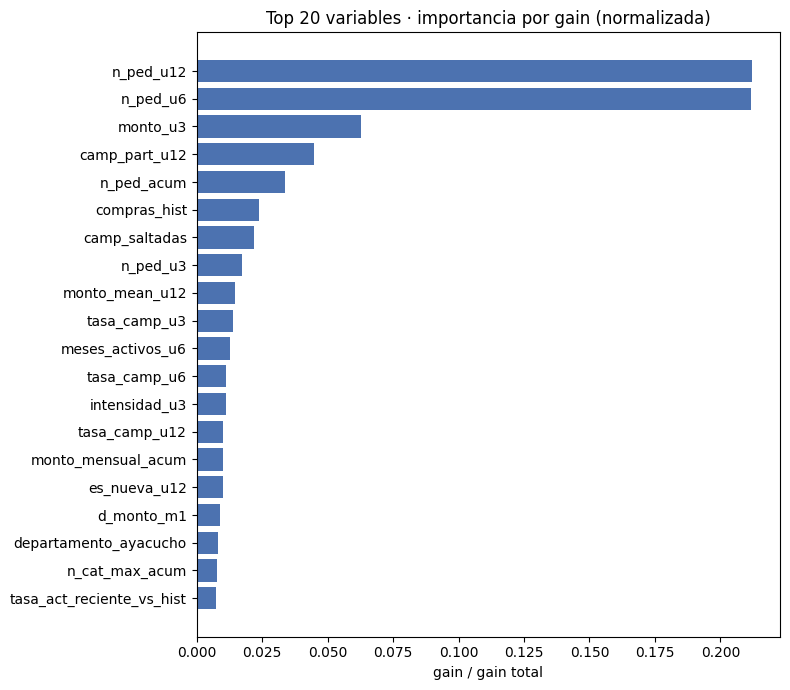

In [3]:
top = imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top["gain_norm"], color="#4c72b0")
ax.set_title("Top 20 variables · importancia por gain (normalizada)")
ax.set_xlabel("gain / gain total")
plt.tight_layout(); plt.show()

## B · Importancia por permutación (sobre el test OOT)

`n_repeats=20` para tener una media y una desviación estándar por variable. La
métrica es `roc_auc`: la caída de AUC al barajar la variable.

In [4]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, X_test, y_test, scoring="roc_auc",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = (pd.DataFrame({"caida_auc_mean": perm.importances_mean,
                         "caida_auc_std": perm.importances_std}, index=FEATS)
           .sort_values("caida_auc_mean", ascending=False))
print("Top 15 por importancia de permutación (caída de AUC):")
print(perm_df.head(15).round(5).to_string())

Top 15 por importancia de permutación (caída de AUC):
                           caida_auc_mean  caida_auc_std
n_ped_u12                         0.01796        0.00585
compras_hist                      0.00937        0.00215
camp_part_u12                     0.00673        0.00312
n_ped_acum                        0.00628        0.00235
camp_saltadas                     0.00606        0.00281
monto_u3                          0.00604        0.00476
n_ped_u6                          0.00541        0.00297
tasa_camp_u12                     0.00186        0.00121
ticket_prom_u3                    0.00147        0.00059
n_ped_u3                          0.00125        0.00106
tasa_act_reciente_vs_hist         0.00117        0.00053
tasa_camp_u3                      0.00115        0.00106
monto_std_u12                     0.00110        0.00042
monto_mean_u12                    0.00096        0.00098
monto_cv_u12                      0.00091        0.00060


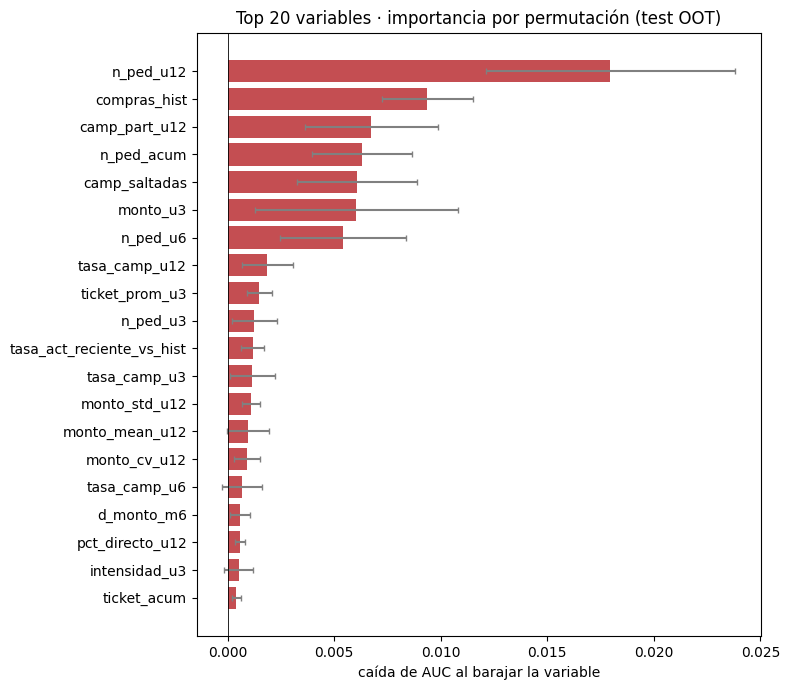

In [5]:
top_p = perm_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_p.index, top_p["caida_auc_mean"], xerr=top_p["caida_auc_std"],
        color="#c44e52", ecolor="gray", capsize=2)
ax.set_title("Top 20 variables · importancia por permutación (test OOT)")
ax.set_xlabel("caída de AUC al barajar la variable")
ax.axvline(0, color="k", lw=0.6)
plt.tight_layout(); plt.show()

## C · Comparación de rankings

Dónde coinciden y dónde discrepan las dos lentes. Discrepancias grandes suelen señalar variables correlacionadas o señal de entrenamiento que no generaliza.

In [6]:
rank = pd.DataFrame({
    "rank_gain": imp["gain"].rank(ascending=False).astype(int),
    "rank_perm": perm_df["caida_auc_mean"].rank(ascending=False).astype(int),
})
rank["delta_rank"] = (rank["rank_gain"] - rank["rank_perm"]).abs()
print("Top 15 por gain, con su rank de permutación:")
print(rank.sort_values("rank_gain").head(15).to_string())

Top 15 por gain, con su rank de permutación:
                    rank_gain  rank_perm  delta_rank
n_ped_u12                   1          1           0
n_ped_u6                    2          7           5
monto_u3                    3          6           3
camp_part_u12               4          3           1
n_ped_acum                  5          4           1
compras_hist                6          2           4
camp_saltadas               7          5           2
n_ped_u3                    8         10           2
monto_mean_u12              9         14           5
tasa_camp_u3               10         12           2
meses_activos_u6           11         29          18
tasa_camp_u6               12         16           4
intensidad_u3              13         19           6
tasa_camp_u12              14          8           6
monto_mensual_acum         15         65          50


## D · Síntesis

_(Completar tras ejecutar.)_

- Variables top que coinciden en ambas lentes → señal robusta y generalizable.
- Variables altas en `gain` pero bajas en permutación → posible sobreajuste de
  entrenamiento o redundancia con otra variable correlacionada.
- Esperado por el dominio: recencia (`meses_desde_compra_previa`, `recencia_norm`),
  intensidad reciente (RFM u3/u6) y nivel histórico (acumulados) deberían dominar.

**Siguiente**: `02_shap.ipynb` desagrega *en qué dirección* y *con qué forma* cada
variable empuja la predicción (la importancia solo dice *cuánto*, no *cómo*).